# Classical codes: simulate, decode, and the limit each one leaves

One pass through the repository's fourth problem class. A code is the null
space of a parity-check matrix `H`; decoding it is inference on the factor
graph with one parity factor per row, which is the structure the other three
notebooks' recursions run on (`docs/tex/textbook.tex`, `sec:ldpc`). The
specialised decoder in `snakes_and_ladders.likelihood.ldpc` is the general
`sum_product` of `message_passing` with one number per message, and this
notebook holds it to that general implementation, to enumeration where
enumeration reaches, and to the density-evolution threshold where it does
not.

Sections 1-6 carry the sparse, iteratively decoded half: Gallager's (3,6)
ensemble at 12, 96 and 996 bits. Sections 7-8 carry the algebraic half,
whose decoders are closed form at every size, and read all of them against
the one bound none of them can pass --- the capacity of the channel
(`sec:ldpc:capacity`). Turbo codes have their own notebook,
[`turbo.ipynb`](turbo.ipynb), and the quantum half is #362's.

**Scope.** Measurements at the ticket's 19,998-bit size, the profile that
decides a Rust kernel, and the optimization framing against the samplers are
parts 2 and 3 of #340 and are not built. §6 stops at 996 bits; the
release-gated test in `tests/regression/likelihood/test_ldpc.py` runs the
full-size code.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
from snakes_and_ladders.likelihood.algebraic import DecodingFailure, hamming_correct
from snakes_and_ladders.likelihood.algebraic import decode as rs_decode
from snakes_and_ladders.likelihood.ldpc import (
    DecodingAlgorithm,
    decode,
    enumerate_codewords,
    erasure_threshold,
    exact_decoding,
)
from snakes_and_ladders.likelihood.message_passing import (
    MessageScheduleName,
    sum_product,
)
from snakes_and_ladders.likelihood.turbo import (
    measure_error_rates,
    uncoded_bit_error_rate,
)
from snakes_and_ladders.qa.style import notebook_style
from snakes_and_ladders.sim.capacity import (
    decibels_at_capacity,
    eb_n0_decibels,
    noise_at_capacity,
    symmetric_capacity,
)
from snakes_and_ladders.sim.elementary_codes import (
    golay_code,
    hamming_code,
    is_perfect,
    repetition_code,
    repetition_error_rate,
    single_parity_check,
)
from snakes_and_ladders.sim.factor_graph import from_parity_check
from snakes_and_ladders.sim.fixtures import fixture
from snakes_and_ladders.sim.galois import bits_from_symbols, symbols_from_bits
from snakes_and_ladders.sim.ldpc import (
    BinaryErasureChannel,
    BinaryInputGaussianChannel,
    BinarySymmetricChannel,
    ParityCheck,
    all_zero_transmission,
    encode,
    generator_matrix,
    gf2_rank,
)
from snakes_and_ladders.sim.reed_solomon import encode as rs_encode
from snakes_and_ladders.sim.reed_solomon import reed_solomon

TINY, MID_SIZE, LONG = (
    fixture("ldpc", tier).params for tier in ("ci", "stress", "release")
)
COLUMN_WEIGHT, ROW_WEIGHT = TINY.column_weight, TINY.row_weight

## 1. A tiny code, and its factor graph

Gallager's construction stacks `column_weight` bands, each a column
permutation of a block-diagonal band of ones, so every column has three ones
and every row six. The rows of one band sum to the all-ones vector, so the
bands make at least two rows dependent and the dimension `k` exceeds
`n - m`: at 12 bits the rate is well above the design rate `1/2`, which is a
finite-size fact and not a defect.

In [2]:
tiny = TINY.code()
k = generator_matrix(tiny).shape[0]
print(f"n = {tiny.n_bits}, m = {tiny.n_checks}, nonzeros = {tiny.n_edges}")
print(
    f"column weights {sorted(set(tiny.column_weights.tolist()))}, row weights {sorted(set(tiny.row_weights.tolist()))}"
)
print(f"k = n - rank H = {k}, so 2**k = {2**k} codewords at rate {k / tiny.n_bits:.3f}")
print("H =")
print(tiny.dense())
graph = from_parity_check(tiny, np.zeros(tiny.n_bits))
print(
    f"factor graph: {len(graph.variables)} variables, {len(graph.factors)} factors, tree: {graph.is_tree()}"
)

n = 12, m = 6, nonzeros = 36
column weights [3], row weights [6]
k = n - rank H = 8, so 2**k = 256 codewords at rate 0.667
H =
[[1 1 1 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 1 1 1]
 [0 0 1 0 1 0 0 1 1 1 0 1]
 [1 1 0 1 0 1 1 0 0 0 1 0]
 [0 0 1 0 1 1 1 1 0 0 0 1]
 [1 1 0 1 0 0 0 0 1 1 1 0]]
factor graph: 12 variables, 18 factors, tree: False


## 2. Three channels, one interface

Every channel returns the log-likelihood ratio
`L_i = log p(y_i | 0) - log p(y_i | 1)`, positive when the received symbol
favours zero. The symmetric channel has one magnitude, `log((1 - p) / p)`;
the erasure channel is zero or certain, with certainty represented as `±30`
because the decoder forms leave-one-out sums by subtraction; the Gaussian
channel's ratio is `2 y / sigma^2`.

In [3]:
for channel in (
    BinarySymmetricChannel(0.15),
    BinaryErasureChannel(0.4),
    BinaryInputGaussianChannel(1.0),
):
    llr = all_zero_transmission(tiny, channel, np.random.default_rng(1))
    print(f"{type(channel).__name__:28s} {np.round(llr, 2)}")

BinarySymmetricChannel       [ 1.73  1.73 -1.73  1.73  1.73  1.73  1.73  1.73  1.73 -1.73  1.73  1.73]
BinaryErasureChannel         [30. 30.  0. 30.  0. 30. 30. 30. 30.  0. 30. 30.]
BinaryInputGaussianChannel   [ 2.69  3.64  2.66 -0.61  3.81  2.89  0.93  3.16  2.73  2.59  2.06  3.09]


## 3. The decoder, held to the oracles

Three oracles share no code with the decoder. On this loopy 12-bit code
both the decoder and the general damped flooding are the Bethe
approximation, so the check is that they reach the *same* fixed point;
enumeration over the 256 codewords gives the exact posteriors, and the gap
between Bethe and exact is measured, not assumed. On a cycle-free code the
tree schedule and enumeration are exact and the decoder must equal both.

In [4]:
llr = all_zero_transmission(
    tiny, BinarySymmetricChannel(0.15), np.random.default_rng(1)
)
decoded = decode(tiny, llr, early_stop=False, max_iterations=3000, tolerance=1e-12)
general = sum_product(
    from_parity_check(tiny, llr),
    schedule=MessageScheduleName.FLOODING,
    tolerance=1e-12,
    max_iterations=3000,
)
general_llr = np.array(
    [
        np.log(general.variable[f"x{i}"][0]) - np.log(general.variable[f"x{i}"][1])
        for i in range(tiny.n_bits)
    ]
)
exact = exact_decoding(tiny, llr)
print(
    f"decoder converged in {decoded.iterations} iterations, general flooding in {general.iterations}"
)
print(
    f"decoder and general posteriors agree within 1e-9: {np.abs(decoded.posterior_llr - general_llr).max() < 1e-9}"
)
print(
    f"Bethe against exact, largest gap in log-odds: {np.abs(decoded.posterior_llr - exact.posterior_llr).max():.3f}"
)
print(
    f"bitwise decision agrees with the exact bitwise MAP on {int((decoded.bits == (exact.posterior_llr < 0)).sum())} of {tiny.n_bits} bits"
)

decoder converged in 52 iterations, general flooding in 41
decoder and general posteriors agree within 1e-9: True
Bethe against exact, largest gap in log-odds: 1.117
bitwise decision agrees with the exact bitwise MAP on 12 of 12 bits


In [5]:
def caterpillar(n_checks: int, degree: int) -> ParityCheck:
    """A cycle-free code: consecutive checks share exactly one bit."""
    n_bits = n_checks * (degree - 1) + 1
    dense = np.zeros((n_checks, n_bits), dtype=np.uint8)
    for j in range(n_checks):
        dense[j, j * (degree - 1) : j * (degree - 1) + degree] = 1
    return ParityCheck.from_dense(dense)


tree = caterpillar(7, 4)
llr = all_zero_transmission(
    tree, BinaryInputGaussianChannel(1.0), np.random.default_rng(2)
)
print(
    f"cycle-free code: n = {tree.n_bits}, m = {tree.n_checks}, tree: {from_parity_check(tree, llr).is_tree()}"
)
exact = exact_decoding(tree, llr)
print(f"enumerated {exact.n_codewords} codewords")
for algorithm in DecodingAlgorithm:
    result = decode(
        tree,
        llr,
        algorithm=algorithm,
        early_stop=False,
        max_iterations=20,
        tolerance=1e-14,
    )
    reference = (
        exact.posterior_llr if algorithm is DecodingAlgorithm.SUM_PRODUCT else None
    )
    if reference is not None:
        print(
            f"{algorithm}: exact posteriors within 1e-12: {np.abs(result.posterior_llr - reference).max() < 1e-12}"
        )
    else:
        print(
            f"{algorithm}: decision is the enumerated ML codeword: {np.array_equal(result.bits, exact.ml_codeword)}"
        )

cycle-free code: n = 22, m = 7, tree: True
enumerated 32768 codewords
sum-product: exact posteriors within 1e-12: True
min-sum: decision is the enumerated ML codeword: True


## 4. A real codeword, and why the zero word suffices

At `n <= 512` Gauss–Jordan elimination over GF(2) gives a systematic
encoder, and `H c = 0` is asserted on every word it returns. Sending a
codeword through the symmetric channel on one noise realization negates the
zero word's ratios exactly where `c_i = 1`; the decoder's updates are odd in
each argument, so its posteriors negate with them and its decision moves by
`c`. That is the identity the all-zero shortcut rests on, checked per
realization rather than argued.

In [6]:
code96 = MID_SIZE.code()
message = np.random.default_rng(4).integers(
    0, 2, size=int(generator_matrix(code96).shape[0])
)
codeword = encode(code96, message)
print(
    f"message bits {message.size}, codeword bits {codeword.size}, weight {int(codeword.sum())}, syndrome zero: {not code96.syndrome(codeword).any()}"
)
channel = BinarySymmetricChannel(0.05)
on_zero = all_zero_transmission(code96, channel, np.random.default_rng(5))
on_codeword = channel.log_likelihood_ratios(codeword, np.random.default_rng(5))
sign = 1.0 - 2.0 * codeword
print(
    f"ratios of the codeword are the zero word's up to sign: {np.array_equal(on_codeword, sign * on_zero)}"
)
zero_decoded, codeword_decoded = decode(code96, on_zero), decode(code96, on_codeword)
print(
    f"posteriors negate exactly: {np.array_equal(codeword_decoded.posterior_llr, sign * zero_decoded.posterior_llr)}"
)
print(
    f"error patterns coincide: {np.array_equal(codeword_decoded.bits ^ codeword, zero_decoded.bits)}"
)
print(
    f"decoded: {zero_decoded.decoded} and {codeword_decoded.decoded}, in {zero_decoded.iterations} and {codeword_decoded.iterations} iterations"
)

message bits 50, codeword bits 96, weight 50, syndrome zero: True
ratios of the codeword are the zero word's up to sign: True
posteriors negate exactly: True
error patterns coincide: True
decoded: True and True, in 9 and 9 iterations


## 5. The 996-bit code against the channel parameter

The nearest multiple of six below 1,000. Bit and block error rates of the
zero word over 20 shared seeds, sum-product first on the symmetric channel,
then both check updates on the Gaussian channel, where min-sum's cheaper
update is the textbook's weaker decoder. The (3,6) ensemble's threshold on
the symmetric channel under belief propagation is `p* = 0.084`.

In [7]:
mid = LONG.code()
SEEDS = range(100, 120)


def error_rates(code, channel, algorithm=DecodingAlgorithm.SUM_PRODUCT):
    """Bit error rate, block error rate and mean iterations of the zero word."""
    bits = blocks = iterations = 0
    for seed in SEEDS:
        result = decode(
            code,
            all_zero_transmission(code, channel, np.random.default_rng(seed)),
            algorithm=algorithm,
        )
        bits += int(result.bits.sum())
        blocks += int(not result.decoded)
        iterations += result.iterations
    return (
        bits / (len(SEEDS) * code.n_bits),
        blocks / len(SEEDS),
        iterations / len(SEEDS),
    )


flips = [0.03, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10]
bsc = [error_rates(mid, BinarySymmetricChannel(p)) for p in flips]
print("symmetric channel, sum-product")
print("   p     BER      FER   iterations")
for p, (ber, fer, its) in zip(flips, bsc, strict=True):
    print(f"  {p:.2f}  {ber:.5f}  {fer:.2f}  {its:5.1f}")

symmetric channel, sum-product
   p     BER      FER   iterations
  0.03  0.00000  0.00    3.1
  0.05  0.00000  0.00    5.7
  0.06  0.00000  0.00   10.2
  0.07  0.00402  0.10   24.0
  0.08  0.02244  0.35   47.4
  0.09  0.04864  0.65   72.2
  0.10  0.07987  0.95   97.2


In [8]:
sigmas = [0.7, 0.8, 0.9]
# Kept rather than printed and dropped: §8 reads these back against the
# Gaussian channel's capacity, and measuring them a second time there would
# pay for the same twenty seeds twice.
GAUSSIAN = {}
print("Gaussian channel")
print("  sigma  algorithm     BER      FER")
for sigma in sigmas:
    for algorithm in DecodingAlgorithm:
        ber, fer, _ = error_rates(mid, BinaryInputGaussianChannel(sigma), algorithm)
        GAUSSIAN[sigma, algorithm] = (ber, fer)
        print(f"  {sigma:.1f}    {algorithm:12s} {ber:.5f}  {fer:.2f}")

Gaussian channel
  sigma  algorithm     BER      FER
  0.7    sum-product  0.00000  0.00
  0.7    min-sum      0.00000  0.00
  0.8    sum-product  0.00000  0.00
  0.8    min-sum      0.01737  0.20


  0.9    sum-product  0.06837  0.80


  0.9    min-sum      0.11150  0.95


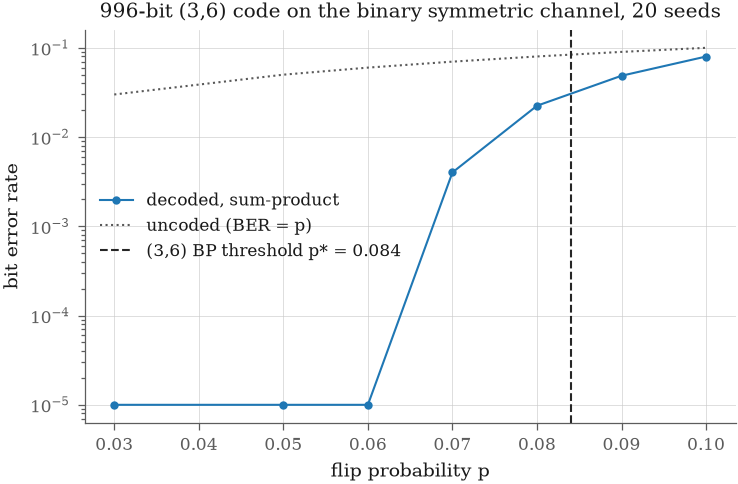

In [9]:
with notebook_style():
    figure, axis = plt.subplots(figsize=(5.6, 3.4))
    axis.plot(
        flips,
        [max(ber, 1e-5) for ber, _, _ in bsc],
        marker="o",
        markersize=3,
        linewidth=1.0,
        label="decoded, sum-product",
    )
    axis.plot(
        flips,
        flips,
        color="0.35",
        linestyle=":",
        linewidth=1.0,
        label="uncoded (BER = p)",
    )
    axis.axvline(
        0.084,
        color="0.15",
        linestyle="--",
        linewidth=1.0,
        label="(3,6) BP threshold p* = 0.084",
    )
    axis.set_yscale("log")
    axis.set_xlabel("flip probability p")
    axis.set_ylabel("bit error rate")
    axis.set_title("996-bit (3,6) code on the binary symmetric channel, 20 seeds")
    axis.legend(frameon=False)
    plt.show()

The waterfall sits below the infinite-length threshold, as a 996-bit member
of the ensemble should: finite length costs rate at fixed error, and the
gap closes as `n` grows.

## 6. Density evolution, and the erasure threshold

On the erasure channel the message-passing decoder's infinite-length
behaviour has a closed form: the erasure probability of a message obeys a
scalar recursion (`app:density-evolution`), and the largest `epsilon` it
drives to zero is the ensemble's threshold. Bisection on that recursion
reproduces the published `0.4294` for (3,6). The 996-bit code is then held
to the *shape* the threshold predicts — every erasure resolved well below
it, most of them surviving well above — rather than to the number itself,
which no code of finite length attains (`sim/CLAUDE.md`).

In [10]:
threshold = erasure_threshold(
    COLUMN_WEIGHT, ROW_WEIGHT, iterations=2000, precision=1e-4
)
print(f"density-evolution threshold for (3,6): {threshold:.4f}")

epsilons = [0.30, 0.35, 0.40, 0.42, 0.44, 0.46, 0.50]
residual = []
for epsilon in epsilons:
    left = []
    for seed in SEEDS:
        llr = all_zero_transmission(
            mid, BinaryErasureChannel(epsilon), np.random.default_rng(seed)
        )
        left.append(
            float(np.mean(decode(mid, llr, max_iterations=300).posterior_llr == 0))
        )
    residual.append(float(np.mean(left)))
print("  epsilon  residual erasure fraction")
for epsilon, fraction in zip(epsilons, residual, strict=True):
    print(f"  {epsilon:.2f}     {fraction:.4f}")

density-evolution threshold for (3,6): 0.4294


  epsilon  residual erasure fraction
  0.30     0.0000
  0.35     0.0000
  0.40     0.0356
  0.42     0.0902
  0.44     0.2352
  0.46     0.3344
  0.50     0.4330


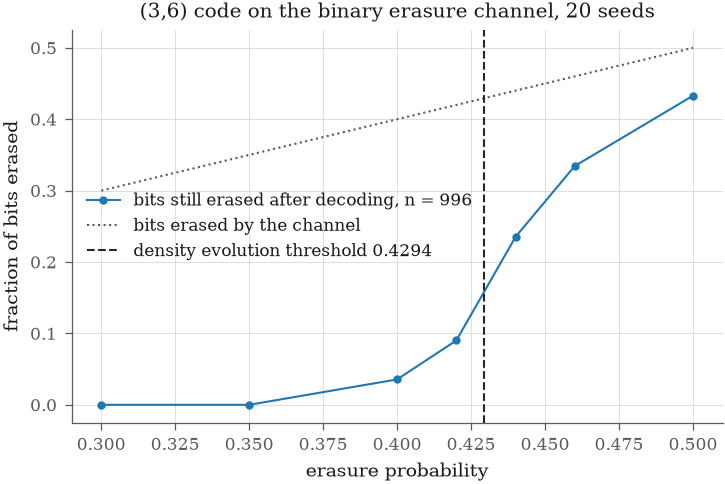

In [11]:
with notebook_style():
    figure, axis = plt.subplots(figsize=(5.6, 3.4))
    axis.plot(
        epsilons,
        residual,
        marker="o",
        markersize=3,
        linewidth=1.0,
        label="bits still erased after decoding, n = 996",
    )
    axis.plot(
        epsilons,
        epsilons,
        color="0.35",
        linestyle=":",
        linewidth=1.0,
        label="bits erased by the channel",
    )
    axis.axvline(
        threshold,
        color="0.15",
        linestyle="--",
        linewidth=1.0,
        label=f"density evolution threshold {threshold:.4f}",
    )
    axis.set_xlabel("erasure probability")
    axis.set_ylabel("fraction of bits erased")
    axis.set_title("(3,6) code on the binary erasure channel, 20 seeds")
    axis.legend(frameon=False)
    plt.show()

## 7. The algebraic half: repetition, Hamming, Golay, Reed–Solomon

Every code above is decoded by iterating messages to a fixed point. These
four are decoded in closed form, which is why they are here: each is a
referee whose cost does not grow with the block, where enumeration's does
(`sim/elementary_codes.py`, `sim/reed_solomon.py`, issue #594).

They are constructed here rather than read from a fixture, unlike §1's code,
and the difference is the draw: Gallager's ensemble needs a generator, so its
member is declared once as a fixture and every caller reads the same one. A
Hamming code is determined by `m`, Golay is unique, and `RS(n, k)` by its
field and rate, so there is no draw to share and no second instance to
diverge from.

The table reads the minimum distance off **every** codeword rather than
taking it from the construction, and checks perfection as an equality over
integers: `2^k sum_{i<=t} C(n, i) == 2^n`, no tolerance.

In [12]:
ALGEBRAIC = {
    "repetition (3,1)": repetition_code(3),
    "parity check (6,5)": single_parity_check(6),
    "Hamming (7,4)": hamming_code(3),
    "Golay (23,12)": golay_code(),
}


def code_shape(code: ParityCheck) -> tuple[int, int, int]:
    """Codeword count, minimum distance and correctable weight, by enumeration."""
    words = enumerate_codewords(code)
    weights = words.sum(axis=1)
    smallest = int(weights[weights > 0].min())
    return words.shape[0], smallest, (smallest - 1) // 2


print(f"{'code':20s} {'n':>3s} {'k':>3s} {'R':>6s} {'d':>3s} {'t':>2s}  perfect")
for name, code in ALGEBRAIC.items():
    n_words, distance, correctable = code_shape(code)
    k = int(round(math.log2(n_words)))
    perfect = is_perfect(code.n_bits, n_words, correctable)
    print(
        f"{name:20s} {code.n_bits:3d} {k:3d} {k / code.n_bits:6.3f} "
        f"{distance:3d} {correctable:2d}  {perfect}"
    )

REED_SOLOMON = reed_solomon(3, 3)
print(
    f"\nRS(7,3) over GF(8): d = {REED_SOLOMON.minimum_distance} = n - k + 1, "
    f"t = {REED_SOLOMON.correctable} symbols, R = "
    f"{REED_SOLOMON.n_message / REED_SOLOMON.n_symbols:.3f}, "
    f"{REED_SOLOMON.n_symbols * REED_SOLOMON.m} bits per block"
)
print(
    "the Singleton bound holds with equality, which no code above does: "
    "repetition 3 = 3, Hamming 3 < 4, Golay 7 < 12"
)

code                   n   k      R   d  t  perfect
repetition (3,1)       3   1  0.333   3  1  True
parity check (6,5)     6   5  0.833   2  0  False
Hamming (7,4)          7   4  0.571   3  1  True
Golay (23,12)         23  12  0.522   7  3  True

RS(7,3) over GF(8): d = 5 = n - k + 1, t = 2 symbols, R = 0.429, 21 bits per block
the Singleton bound holds with equality, which no code above does: repetition 3 = 3, Hamming 3 < 4, Golay 7 < 12


### Each decoder against its own closed form

A bounded-distance decoder's block error rate is **exactly** the probability
that more than `t` symbols are wrong: past `t` the sent word is farther than
`t` from what arrived, so a decoder that only returns words within `t` cannot
return it. That makes the binomial tail an oracle and not an approximation,
and the pins below are what the implementations are held to. For the perfect
codes the same tail is the *maximum-likelihood* rate too, since the spheres
of radius `t` cover the space and leave no word with a nearer neighbour.

Reed–Solomon's channel is the binary one its symbols are sent over: a symbol
survives when all `m = 3` of its bits do, so its error probability is
`1 - (1 - p)^3` and not `p` (`sim/galois.py`'s packing).

One decoder here has no closed form, and is the point of the comparison:
sum-product on Golay's parity check — eleven rows of weight eight over 23
bits, where **every one of the 55 row pairs shares at least two columns**, so
the graph is dense in four-cycles and the approximation has nothing to be
exact about.

In [13]:
BSC_PIN = 0.10
RS_PIN = 0.05


def bounded_distance_rate(n: int, error: float, correctable: int) -> float:
    """`P(more than t of n symbols wrong)`, the exact bounded-distance rate."""
    return 1.0 - sum(
        math.comb(n, weight) * error**weight * (1.0 - error) ** (n - weight)
        for weight in range(correctable + 1)
    )


def zero_word_failures(code, decoder, flip, draws):
    """Block error rate of the all-zero word under `decoder`, over `draws` seeds."""
    failures = 0
    for seed in range(draws):
        llr = all_zero_transmission(
            code, BinarySymmetricChannel(flip), np.random.default_rng(seed)
        )
        failures += int(bool(np.any(decoder(code, llr))))
    return failures / draws


def reed_solomon_failures(flip, draws, rng):
    """Refusals and wrong codewords from the algebraic decoder, over `draws` blocks."""
    refused = wrong = 0
    for _ in range(draws):
        sent = rs_encode(
            REED_SOLOMON, rng.integers(0, REED_SOLOMON.field.order, size=3)
        )
        bits = bits_from_symbols(sent, REED_SOLOMON.m) ^ (
            rng.random(REED_SOLOMON.n_symbols * REED_SOLOMON.m) < flip
        )
        received = symbols_from_bits(bits.astype(np.int64), REED_SOLOMON.m)
        try:
            recovered = rs_decode(REED_SOLOMON, received)
        except DecodingFailure:
            refused += 1
            continue
        wrong += int(not np.array_equal(recovered, sent))
    return refused, wrong


golay = ALGEBRAIC["Golay (23,12)"]
symbol_error = 1.0 - (1.0 - RS_PIN) ** REED_SOLOMON.m
refused, wrong = reed_solomon_failures(RS_PIN, 1000, np.random.default_rng(594))

MEASURED = [
    (
        "repetition (3,1), ML",
        BSC_PIN,
        2000,
        zero_word_failures(
            ALGEBRAIC["repetition (3,1)"],
            lambda c, ratios: exact_decoding(c, ratios).ml_codeword,
            BSC_PIN,
            2000,
        ),
        repetition_error_rate(3, crossover=BSC_PIN),
    ),
    (
        "Hamming (7,4), syndrome",
        BSC_PIN,
        2000,
        zero_word_failures(
            ALGEBRAIC["Hamming (7,4)"],
            lambda c, ratios: hamming_correct(c, 3, (ratios < 0).astype(np.int64)),
            BSC_PIN,
            2000,
        ),
        bounded_distance_rate(7, BSC_PIN, 1),
    ),
    (
        "Golay (23,12), ML",
        BSC_PIN,
        300,
        zero_word_failures(
            golay, lambda c, ratios: exact_decoding(c, ratios).ml_codeword, BSC_PIN, 300
        ),
        bounded_distance_rate(23, BSC_PIN, 3),
    ),
    (
        "RS(7,3)/GF(8), Berlekamp-Massey",
        RS_PIN,
        1000,
        (refused + wrong) / 1000,
        bounded_distance_rate(7, symbol_error, 2),
    ),
]

print(
    f"{'encoder, decoder':32s} {'p':>5s} {'draws':>6s} {'measured':>9s} "
    f"{'closed form':>12s} {'|gap|/se':>9s}"
)
for name, flip, draws, measured, analytic in MEASURED:
    error = math.sqrt(analytic * (1.0 - analytic) / draws)
    print(
        f"{name:32s} {flip:5.2f} {draws:6d} {measured:9.4f} {analytic:12.4f} "
        f"{abs(measured - analytic) / error:9.2f}"
    )
print(
    f"\nRS past its radius, at p = {RS_PIN}: {refused} blocks refused and "
    f"{wrong} decoded to a wrong codeword, of 1000"
)

GOLAY_SUM_PRODUCT = zero_word_failures(
    golay, lambda c, ratios: decode(c, ratios).bits, BSC_PIN, 300
)
print(
    f"Golay under sum-product, same p and seeds: {GOLAY_SUM_PRODUCT:.4f} against "
    f"{bounded_distance_rate(23, BSC_PIN, 3):.4f} under ML, a factor of "
    f"{GOLAY_SUM_PRODUCT / bounded_distance_rate(23, BSC_PIN, 3):.1f}"
)

encoder, decoder                     p  draws  measured  closed form  |gap|/se
repetition (3,1), ML              0.10   2000    0.0280       0.0280      0.00
Hamming (7,4), syndrome           0.10   2000    0.1530       0.1497      0.41
Golay (23,12), ML                 0.10    300    0.2300       0.1927      1.64
RS(7,3)/GF(8), Berlekamp-Massey   0.05   1000    0.0600       0.0650      0.64

RS past its radius, at p = 0.05: 51 blocks refused and 9 decoded to a wrong codeword, of 1000


Golay under sum-product, same p and seeds: 0.5067 against 0.1927 under ML, a factor of 2.6


## 8. The Shannon limit, and the gap each pair leaves

Every number above says what one decoder does. Capacity says what **no**
decoder of that rate does: past `C(noise) = R` no code of rate `R` is
reliable at any length, on any of the three channels
(`sim/capacity.py`, `sec:ldpc:capacity`). It is the only referee here that
bounds a result from above without running anything, and it is a *converse*
— it does not promise a code, it forbids one.

Two kinds of claim are plotted below and they are not the same kind. A
finite-length code's crossing of a chosen error rate is a property of that
code at that length; an ensemble's threshold is a property of the ensemble
at infinite length. Both are read against the same boundary, and only the
second is comparable to it directly.

In [14]:
TARGET = 1e-2


def crossing(curve, target=TARGET, low=1e-5, high=0.49):
    """The flip probability where a monotone error-rate curve reaches `target`."""
    while high - low > 1e-7:
        middle = 0.5 * (low + high)
        if curve(middle) < target:
            low = middle
        else:
            high = middle
    return 0.5 * (low + high)


PAIRS = {
    "repetition (3,1), ML": (1 / 3, lambda p: repetition_error_rate(3, crossover=p)),
    "RS(7,3)/GF(8), Berlekamp-Massey": (
        3 / 7,
        lambda p: bounded_distance_rate(7, 1.0 - (1.0 - p) ** 3, 2),
    ),
    "Golay (23,12), ML": (12 / 23, lambda p: bounded_distance_rate(23, p, 3)),
    "Hamming (7,4), syndrome": (4 / 7, lambda p: bounded_distance_rate(7, p, 1)),
}

print(
    f"{'encoder, decoder':32s} {'R':>6s} {'p at 1e-2':>10s} {'p* limit':>9s} {'ratio':>6s}"
)
LIMITS = {}
for name, (rate, curve) in PAIRS.items():
    reached = crossing(curve)
    limit = noise_at_capacity(rate, BinarySymmetricChannel)
    LIMITS[name] = (rate, reached, limit)
    print(
        f"{name:32s} {rate:6.3f} {reached:10.4f} {limit:9.4f} {limit / reached:5.1f}x"
    )

LDPC_RATE = (mid.n_bits - gf2_rank(mid.dense())) / mid.n_bits
LDPC_THRESHOLD = 0.084
print(
    f"\n(3,6) at n = {mid.n_bits}: R = {LDPC_RATE:.4f} against the design rate "
    f"0.5, so its limit is p* = "
    f"{noise_at_capacity(LDPC_RATE, BinarySymmetricChannel):.4f}"
)
print(
    f"the ensemble's BP threshold p* = {LDPC_THRESHOLD} is a factor of "
    f"{noise_at_capacity(LDPC_RATE, BinarySymmetricChannel) / LDPC_THRESHOLD:.2f} "
    "inside it, at infinite length"
)
print(
    f"on the erasure channel: threshold {threshold:.4f} against the limit "
    f"{noise_at_capacity(LDPC_RATE, BinaryErasureChannel):.4f}, leaving "
    f"{100 * (1 - threshold / noise_at_capacity(LDPC_RATE, BinaryErasureChannel)):.1f}%"
    " of the channel unused"
)
print(
    f"on the Gaussian channel the limit at this rate is sigma* = "
    f"{noise_at_capacity(LDPC_RATE, BinaryInputGaussianChannel):.4f}; §5 decodes "
    "at 0.7, 0.8 and 0.9"
)

encoder, decoder                      R  p at 1e-2  p* limit  ratio
repetition (3,1), ML              0.333     0.0589    0.1740   3.0x
RS(7,3)/GF(8), Berlekamp-Massey   0.429     0.0242    0.1352   5.6x
Golay (23,12), ML                 0.522     0.0376    0.1029   2.7x
Hamming (7,4), syndrome           0.571     0.0227    0.0876   3.9x

(3,6) at n = 996: R = 0.5020 against the design rate 0.5, so its limit is p* = 0.1094
the ensemble's BP threshold p* = 0.084 is a factor of 1.30 inside it, at infinite length
on the erasure channel: threshold 0.4294 against the limit 0.4980, leaving 13.8% of the channel unused
on the Gaussian channel the limit at this rate is sigma* = 0.9757; §5 decodes at 0.7, 0.8 and 0.9


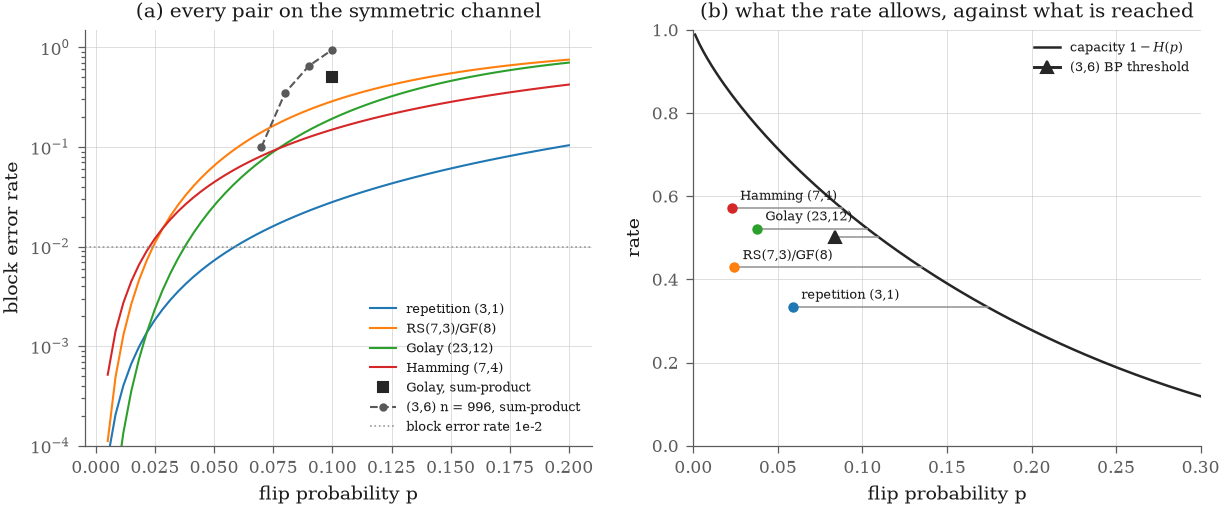

In [15]:
flip_grid = np.linspace(0.005, 0.2, 60)
with notebook_style():
    figure, (left, right) = plt.subplots(1, 2, figsize=(9.6, 3.6))

    for name, (_, curve) in PAIRS.items():
        left.plot(
            flip_grid,
            [curve(p) for p in flip_grid],
            linewidth=1.0,
            label=name.rsplit(", ", 1)[0],
        )
    left.plot(
        [BSC_PIN],
        [GOLAY_SUM_PRODUCT],
        marker="s",
        markersize=5,
        linestyle="none",
        color="0.15",
        label="Golay, sum-product",
    )
    failed = [(p, fer) for p, (_, fer, _) in zip(flips, bsc, strict=True) if fer > 0]
    left.plot(
        [p for p, _ in failed],
        [fer for _, fer in failed],
        marker="o",
        markersize=3,
        linewidth=1.0,
        linestyle="--",
        color="0.35",
        label=f"(3,6) n = {mid.n_bits}, sum-product",
    )
    left.axhline(
        TARGET, color="0.6", linewidth=0.8, linestyle=":", label="block error rate 1e-2"
    )
    left.set_yscale("log")
    left.set_ylim(1e-4, 1.5)
    left.set_xlabel("flip probability p")
    left.set_ylabel("block error rate")
    left.set_title("(a) every pair on the symmetric channel")
    left.legend(frameon=False, fontsize="x-small")

    boundary = np.linspace(0.001, 0.49, 200)
    right.plot(
        boundary,
        [symmetric_capacity(p) for p in boundary],
        color="0.15",
        linewidth=1.2,
        label="capacity $1 - H(p)$",
    )
    for name, (rate, reached, limit) in LIMITS.items():
        right.plot([reached, limit], [rate, rate], color="0.6", linewidth=0.8)
        right.plot([reached], [rate], marker="o", markersize=4)
        right.annotate(
            name.rsplit(", ", 1)[0],
            (reached, rate),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize="x-small",
        )
    right.plot(
        [LDPC_THRESHOLD, noise_at_capacity(LDPC_RATE, BinarySymmetricChannel)],
        [LDPC_RATE, LDPC_RATE],
        color="0.6",
        linewidth=0.8,
    )
    right.plot(
        [LDPC_THRESHOLD],
        [LDPC_RATE],
        marker="^",
        markersize=6,
        color="0.15",
        label="(3,6) BP threshold",
    )
    right.set_xlim(0.0, 0.3)
    right.set_ylim(0.0, 1.0)
    right.set_xlabel("flip probability p")
    right.set_ylabel("rate")
    right.set_title("(b) what the rate allows, against what is reached")
    right.legend(frameon=False, fontsize="x-small", loc="upper right")
    plt.show()

Panel (b) reads horizontally: the segment from each marker to the boundary
is the noise that code's rate entitles it to and its decoder does not
deliver. The algebraic pairs give up a factor of 2.7 to 5.6 at a block error
rate of `1e-2`, and each is a finite block — 3, 7, 21 or 23 bits — where
capacity is a statement about arbitrarily long ones, so part of every
segment is length and not decoding.

The triangle is the only marker on the same footing as the boundary: an
ensemble's threshold is an infinite-length claim, and the (3,6) ensemble
leaves a factor of 1.30 on the symmetric channel and 13.8% of the erasure
channel — read against the rate this member actually carries, 0.5020 rather
than the design 0.5, which is what §1's dependent rows buy and what moves
14.1% to 13.8%. That is the honest comparison, and it is the one §6 measures
a 996-bit member against.

The dashed line is the 996-bit code under sum-product, plotted where a block
failed: at `p <= 0.06` none of the twenty did, and twenty seeds cannot
resolve a rate below 0.05, so those settings are absent rather than drawn at
a floor.

Rate is the other half of the reading, and the repetition code makes the
case: it has the mildest limit of the four, `p* = 0.174`, because it spends
two thirds of the channel on redundancy — and it still gives up a factor of
3.0, so nothing about the gap is bought by lowering the rate.

### The same question on the Gaussian channel

The symmetric channel above throws away the one thing the Gaussian channel
gives for free: **how reliable each bit is**. The panel below puts every
family on the axis a link budget is actually written in, `E_b/N_0` in dB,
where the limit at rate 1/2 is the **+0.187 dB** every coding text quotes and
`sim.capacity` recovers from the integral rather than from the quoted
`sigma*`.

Three kinds of curve, and the difference between them is the point:

* the **algebraic** codes decode a hard decision, so the channel is first
  collapsed to a crossover — `Q(sqrt(2 R E_b/N_0))`, which is
  `likelihood.turbo`'s uncoded closed form evaluated at the *symbol* energy
  `R E_b` — and their block error rate follows in closed form;
* the **996-bit (3,6) code** reads the reliabilities, measured in §5 at three
  noise scales under both check updates and read back here rather than
  re-simulated;
* the **turbo code** is the family built to close this gap, measured on its
  own declared instance (`docs/nb/turbo.ipynb` carries the rest of it), which
  is the 13 s this notebook spends and the reason the panel exists.

In [16]:
TURBO = fixture("turbo", "stress").params
turbo_code = TURBO.code()
# Tail bits are energy spent, so they are charged to the rate: the code sends
# `3K + 4m` symbols for `K` message bits (`likelihood.turbo.noise_scale`).
TURBO_RATE = TURBO.message_length / (3 * TURBO.message_length + 4 * TURBO.memory)
turbo_decibels = list(TURBO.eb_n0_db)
turbo_failures = [
    measure_error_rates(
        turbo_code,
        point,
        TURBO.frames,
        np.random.default_rng(TURBO.seed),
        iterations=TURBO.iterations,
    ).frame_error_rate[-1]
    for point in turbo_decibels
]
print(
    f"turbo K = {TURBO.message_length}, {TURBO.frames} frames per point, "
    f"{TURBO.iterations} iterations, rate {TURBO_RATE:.4f} with the tail bits "
    "charged"
)
print("  E_b/N_0   frame error rate")
for point, failed in zip(turbo_decibels, turbo_failures, strict=True):
    print(f"  {point:5.1f} dB   {failed:.2f}")
print(f"\nits limit is {decibels_at_capacity(TURBO_RATE):+.3f} dB")

turbo K = 256, 50 frames per point, 8 iterations, rate 0.3299 with the tail bits charged
  E_b/N_0   frame error rate
    0.0 dB   0.72
    0.4 dB   0.56
    0.8 dB   0.34
    1.2 dB   0.16
    1.6 dB   0.00
    2.0 dB   0.00

its limit is -0.508 dB


In [17]:
def hard_decision_flip(point: float, rate: float) -> float:
    """The crossover a hard decision leaves at this `E_b/N_0` and rate.

    `Q(sqrt(2 R E_b/N_0))`: the uncoded closed form at the *symbol* energy
    `R E_b`, which in dB is the point shifted by `10 log10 R`. Written through
    `likelihood.turbo.uncoded_bit_error_rate` rather than a second `erfc`.
    """
    return float(uncoded_bit_error_rate(point + 10.0 * math.log10(rate))[0])


def decibels_at_target(rate: float, curve, target=TARGET) -> float:
    """The `E_b/N_0` where a hard-decision curve reaches `target`."""
    low, high = -2.0, 20.0
    while high - low > 1e-6:
        middle = 0.5 * (low + high)
        if curve(hard_decision_flip(middle, rate)) > target:
            low = middle
        else:
            high = middle
    return 0.5 * (low + high)


HARD_DECISION = {
    "RS(7,3)/GF(8)": (
        3 / 7,
        lambda p: bounded_distance_rate(7, 1.0 - (1.0 - p) ** 3, 2),
    ),
    "Golay (23,12)": (12 / 23, lambda p: bounded_distance_rate(23, p, 3)),
    "Hamming (7,4)": (4 / 7, lambda p: bounded_distance_rate(7, p, 1)),
}

print(f"{'code':16s} {'R':>6s} {'dB at 1e-2':>11s} {'limit dB':>9s} {'gap dB':>7s}")
for name, (rate, curve) in HARD_DECISION.items():
    reached = decibels_at_target(rate, curve)
    limit = decibels_at_capacity(rate)
    print(
        f"{name:16s} {rate:6.3f} {reached:11.2f} {limit:+9.3f} {reached - limit:7.2f}"
    )

for name, rate, point in (
    ("(3,6) n = 996", LDPC_RATE, eb_n0_decibels(0.9, LDPC_RATE)),
    ("turbo K = 256", TURBO_RATE, 1.2),
):
    print(
        f"{name:16s} {rate:6.3f} {point:11.2f} {decibels_at_capacity(rate):+9.3f} "
        f"{point - decibels_at_capacity(rate):7.2f}   (measured, not at 1e-2)"
    )

code                  R  dB at 1e-2  limit dB  gap dB
RS(7,3)/GF(8)     0.429        6.58    -0.122    6.70
Golay (23,12)     0.522        4.82    +0.287    4.53
Hamming (7,4)     0.571        5.45    +0.530    4.92
(3,6) n = 996     0.502        0.90    +0.196    0.70   (measured, not at 1e-2)
turbo K = 256     0.330        1.20    -0.508    1.71   (measured, not at 1e-2)


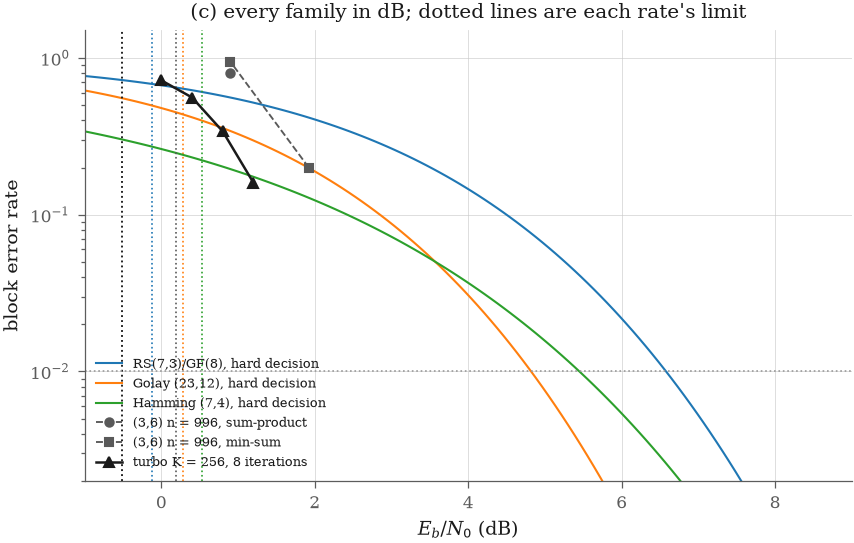

In [18]:
grid = np.linspace(-1.0, 9.0, 120)
with notebook_style():
    figure, axis = plt.subplots(figsize=(6.6, 3.9))
    for name, (rate, curve) in HARD_DECISION.items():
        (line,) = axis.plot(
            grid,
            [curve(hard_decision_flip(point, rate)) for point in grid],
            linewidth=1.0,
            label=f"{name}, hard decision",
        )
        axis.axvline(
            decibels_at_capacity(rate),
            color=line.get_color(),
            linestyle=":",
            linewidth=0.8,
        )

    for algorithm, marker in zip(DecodingAlgorithm, ("o", "s"), strict=False):
        measured = [
            (eb_n0_decibels(sigma, LDPC_RATE), GAUSSIAN[sigma, algorithm][1])
            for sigma in sigmas
            if GAUSSIAN[sigma, algorithm][1] > 0
        ]
        axis.plot(
            [point for point, _ in measured],
            [failed for _, failed in measured],
            marker=marker,
            markersize=4,
            linestyle="--",
            linewidth=0.9,
            color="0.35",
            label=f"(3,6) n = 996, {algorithm}",
        )
    axis.axvline(
        decibels_at_capacity(LDPC_RATE), color="0.35", linestyle=":", linewidth=0.8
    )

    failed_at = [
        (point, failed)
        for point, failed in zip(turbo_decibels, turbo_failures, strict=True)
        if failed > 0
    ]
    axis.plot(
        [point for point, _ in failed_at],
        [failed for _, failed in failed_at],
        marker="^",
        markersize=5,
        linewidth=1.2,
        color="0.1",
        label=f"turbo K = {TURBO.message_length}, {TURBO.iterations} iterations",
    )
    axis.axvline(
        decibels_at_capacity(TURBO_RATE),
        color="0.1",
        linestyle=":",
        linewidth=0.9,
    )
    axis.axhline(TARGET, color="0.6", linewidth=0.8, linestyle=":")
    axis.set_yscale("log")
    axis.set_ylim(2e-3, 1.5)
    axis.set_xlim(-1.0, 9.0)
    axis.set_xlabel("$E_b / N_0$ (dB)")
    axis.set_ylabel("block error rate")
    axis.set_title("(c) every family in dB; dotted lines are each rate's limit")
    axis.legend(frameon=False, fontsize="x-small", loc="lower left")
    plt.show()

Read the dotted lines first: every rate here has nearly the same limit,
between `-0.51` and `+0.53` dB, so the spread along the axis is decoding and
block length and almost nothing to do with rate.

The algebraic codes need **4.82 dB** (Golay), **5.45 dB** (Hamming) and
**6.58 dB** (Reed–Solomon) to reach a block error rate of `1e-2`, against
limits of `+0.29`, `+0.53` and `-0.12` — gaps of **4.5 to 6.7 dB**. Roughly
2 dB of that is the hard decision itself, which throws away the magnitude the
channel supplies before decoding begins; the rest is a block of 7, 21 or 23
bits where capacity speaks about arbitrarily long ones.

**The measured points are not at that error rate, and the table says so.**
The turbo code sits 1.71 dB past its limit while failing 8 of 50 frames, and
the 996-bit code 0.70 dB past its while failing 16 of 20 blocks. What they
establish is not a smaller gap at `1e-2` — neither was measured there — but
that a soft-decision iterative decoder is still working at 0.9 and 1.2 dB,
where every algebraic curve above is still failing essentially every block.

That is the division of labour between the two halves of this notebook: the
algebraic codes decode in closed form at every length and leave 4.5 dB of the
channel unclaimed, and the iterative ones claim it and are refereed by
nothing sharper than a Monte Carlo count and an ensemble threshold.

## 9. A second construction: bicycle codes

Gallager's ensemble fixes the degrees and leaves the rest to a permutation.
A bicycle code (MacKay, Mitchison and McFadden 2004) fixes the matrix:
`H = [A | A^T]` for a circulant `A` whose first row carries `w` ones, with
rows then deleted to raise the rate. A column of the left half is a column
of `A` and a column of the right half is a row of it, so every column has
weight `w` and every row `2w` — the (3,6) degrees at `w = 3`, matched to the
fixture of §1 in length, degrees and design rate.

Two properties come free. A circulant and its transpose are polynomials in
the cyclic shift, so they commute and `H H^T = 0` over GF(2): the condition
a Calderbank–Shor–Steane quantum code puts on its parity-check matrices,
which nothing classical needs. And every row has even weight, so the
all-ones word is a codeword whatever is drawn.

In [19]:
bicycle = fixture("bicycle", "ci").params.code()
dense = bicycle.dense().astype(int)
print(f"n = {bicycle.n_bits}, m = {bicycle.n_checks}, nonzeros = {bicycle.n_edges}")
print(
    f"column weights {sorted(set(bicycle.column_weights.tolist()))}, "
    f"row weights {sorted(set(bicycle.row_weights.tolist()))}"
)
print(
    f"circulant first row: {np.flatnonzero(dense[0, : bicycle.n_bits // 2]).tolist()}"
)
print(f"H H^T mod 2 nonzeros: {int(((dense @ dense.T) % 2).sum())}")
print(
    f"syndrome of the all-ones word: {bicycle.syndrome(np.ones(bicycle.n_bits, dtype=np.uint8))}"
)
print("H =")
print(bicycle.dense())

n = 12, m = 6, nonzeros = 36
column weights [3], row weights [6]
circulant first row: [1, 2, 5]
H H^T mod 2 nonzeros: 0
syndrome of the all-ones word: [0 0 0 0 0 0]
H =
[[0 1 1 0 0 1 0 1 0 0 1 1]
 [1 0 1 1 0 0 1 0 1 0 0 1]
 [0 1 0 1 1 0 1 1 0 1 0 0]
 [0 0 1 0 1 1 0 1 1 0 1 0]
 [1 0 0 1 0 1 0 0 1 1 0 1]
 [1 1 0 0 1 0 1 0 0 1 1 0]]


Enumeration settles what the construction bought at this length. The
Gallager draw of §1 carries two dependent rows, so its dimension exceeds
`n - m`; the bicycle matrix here has full rank, and its lightest nonzero
codeword is twice as heavy.

In [20]:
for name, code in (("bicycle", bicycle), ("Gallager (3,6)", tiny)):
    words = enumerate_codewords(code)
    weights = words.sum(axis=1)
    dimension = int(np.log2(words.shape[0]))
    print(
        f"{name:16s} k = {dimension}, rate {dimension / code.n_bits:.3f}, "
        f"{words.shape[0]} codewords, minimum distance {int(weights[weights > 0].min())}"
    )

bicycle          k = 6, rate 0.500, 64 codewords, minimum distance 4
Gallager (3,6)   k = 8, rate 0.667, 256 codewords, minimum distance 2


### The decoder against the two exact decodings

The same oracles as §3, on the new matrix. Over 200 transmissions of the
all-zero word the enumerated bitwise MAP makes fewer bit errors than the
decoder and the maximum-likelihood codeword fewer block errors, which is
what each minimizes; the gap is what the Bethe approximation costs on a
graph whose girth is four.

In [21]:
params = fixture("bicycle", "ci").params
print("                 exact bits  decoder bits  exact blocks  decoder blocks")
for label, channel in (
    ("symmetric", params.symmetric_channel()),
    ("Gaussian ", params.gaussian_channel()),
):
    counts = np.zeros(4, dtype=int)
    for seed in range(200, 400):
        llr = all_zero_transmission(bicycle, channel, np.random.default_rng(seed))
        decoded = decode(bicycle, llr, max_iterations=200)
        exact = exact_decoding(bicycle, llr)
        counts += [
            int((exact.posterior_llr < 0.0).sum()),
            int(decoded.bits.sum()),
            int(np.any(exact.ml_codeword)),
            int(np.any(decoded.bits)),
        ]
    print(
        f"  {label}    {counts[0]:11d} {counts[1]:13d} {counts[2]:13d} {counts[3]:15d}"
    )

                 exact bits  decoder bits  exact blocks  decoder blocks


  symmetric            295           348            30             171


  Gaussian             129           285            29             110


### Against a random construction at 96 bits

Same length, same degrees, and the bicycle code's dimension is the smaller
of the two, so nothing below is bought rate. Twenty shared channel
realizations per setting; a block counts as failed when the decoder reaches
its iteration cap without a codeword.

In [22]:
bicycle96 = fixture("bicycle", "stress").params.code()
gallager96 = fixture("ldpc", "stress").params.code()
settings = [
    ("BSC p=0.02", BinarySymmetricChannel(0.02)),
    ("BSC p=0.06", BinarySymmetricChannel(0.06)),
    ("BEC e=0.30", BinaryErasureChannel(0.30)),
    ("BEC e=0.40", BinaryErasureChannel(0.40)),
    ("AWGN s=0.7", BinaryInputGaussianChannel(0.7)),
    ("AWGN s=0.9", BinaryInputGaussianChannel(0.9)),
]


def failures(code, channel):
    """Blocks of the 20 shared seeds the decoder left without a codeword."""
    return sum(
        not decode(
            code,
            all_zero_transmission(code, channel, np.random.default_rng(seed)),
            max_iterations=200,
        ).decoded
        for seed in range(100, 120)
    )


print(
    f"k: bicycle {generator_matrix(bicycle96).shape[0]}, "
    f"Gallager {generator_matrix(gallager96).shape[0]}, of n = 96"
)
measured = [(failures(bicycle96, c), failures(gallager96, c)) for _, c in settings]
print("               bicycle  Gallager   (blocks failed of 20)")
for (label, _), (left, right) in zip(settings, measured, strict=True):
    print(f"  {label}   {left:7d} {right:9d}")

k: bicycle 48, Gallager 50, of n = 96


               bicycle  Gallager   (blocks failed of 20)
  BSC p=0.02         2         1
  BSC p=0.06        12         5
  BEC e=0.30        20         3
  BEC e=0.40        20        12
  AWGN s=0.7         9         1
  AWGN s=0.9        20        15


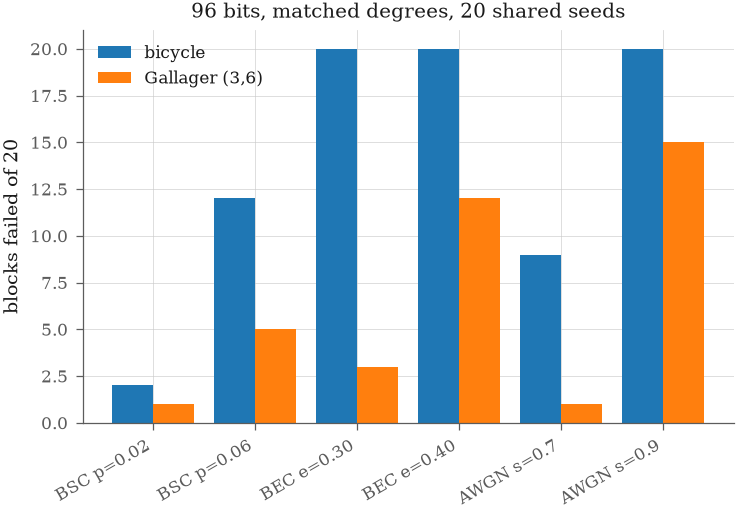

In [23]:
with notebook_style():
    figure, axis = plt.subplots(figsize=(5.6, 3.4))
    offsets = np.arange(len(settings))
    axis.bar(offsets - 0.2, [b for b, _ in measured], width=0.4, label="bicycle")
    axis.bar(offsets + 0.2, [g for _, g in measured], width=0.4, label="Gallager (3,6)")
    axis.set_xticks(offsets)
    axis.set_xticklabels([label for label, _ in settings], rotation=30, ha="right")
    axis.set_ylabel("blocks failed of 20")
    axis.set_title("96 bits, matched degrees, 20 shared seeds")
    axis.legend(frameon=False)
    plt.show()

The circulant is paid for in cycles: the bicycle code loses at every
setting, and the erasure channel most of all. The density-evolution
threshold of §6 does not referee it either — a threshold is a property of
the ensemble a code is drawn from, and this code is not drawn from that one,
which is why its fixture states no oracle. What the construction is carried
for is `H H^T = 0`, and that belongs to the quantum half.

## Further work

What this notebook could not demonstrate, because the feature is not built.
Each line names the issue that carries it.

- **The code at size (#340, part 2).** Bit and block error rates against
  `p`, `epsilon` and `sigma` at 19,998 bits over shared seeds, iterations to
  convergence, wall clock and peak memory against the 16 GB requirement, and
  the profile that decides whether a Rust kernel over the same offsets
  follows. §5 and §6 stop at 996 bits; the release gate runs the full-size
  erasure bracket.
- **Decoding as optimization (#340, part 3).** MAP decoding as energy
  minimization under hard parity constraints, compared at matched
  evaluations through `opt.budget` against the Gibbs sampler, the annealer
  and single-site descent on enumerable codes, with the enumerated ML
  codeword as referee.
- **A linear-time encoder (#340).** §4's Gauss–Jordan encoder stops at 512
  bits; past it every simulation sends the zero word on the symmetry
  argument §4 checks.
- **Soft-decision decoding of the algebraic codes (#805).**
  §7's decoders read hard decisions: a syndrome, or a locator
  polynomial over `GF(2^m)`. The Gaussian channel's capacity is computed in
  §8 and no algebraic code is measured against it, because generalized
  minimum-distance decoding — the route from a reliability to an algebraic
  decoder — is not built. What §8 reports on that channel is the limit
  alone.
- **The quantum half (#362).** §9 asserts `H H^T = 0` and stops there. A
  quantum code decodes a syndrome rather than a word, and does it with
  degeneracy: distinct errors sharing a syndrome act identically on the
  codespace, so agreement with the maximum-likelihood codeword — the oracle
  §3 and §9 rest on — is the wrong question, and what replaces it is that
  ticket's first job.
